# Graph-Based Insights for EV Charging Station Planning in Germany

This project analyzes a geographic proximity graph of German cities to support strategic planning for electric vehicle (EV) charging station expansion.

## Overview

This project analyzes a city network in Germany for electric vehicle (EV) charging station planning.

In this network:

- Nodes represent 126 major German cities.
- Edges represent city connections under 150 km.
- Each city also has population and location information.

The main goal is to find useful locations for new EV charging stations.

This project answers three questions:

- Which cities are important central hubs?
- Which city groups can support better regional coverage?
- Which cities are less connected and may need better charging access?

The results can help an EV charging company decide where to build new stations. This can improve travel between cities, reduce network gaps, and support future EV infrastructure growth.

##  The Data

The dataset is a proximity graph of German cities.

It was created from real-world city and geographic data. The main data sources are SimpleMaps and GADM.

In this graph:

- Nodes represent 126 major German cities.
- Each node has population, latitude, and longitude information.
- Edges represent geographic proximity.
- Two cities are connected if they are less than 150 km apart.
- Each edge has a distance value in kilometers.
- Edge weight is calculated as `1 / distance`, so closer cities have stronger connections.

This graph is suitable for the project because it shows how German cities are connected by distance. This structure can help identify central cities, regional groups, and less connected areas for EV charging station planning.

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import community as community_louvain
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import girvan_newman


In [36]:
# Load the graph
G = nx.read_graphml("data/germany_city_graph.graphml")

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 126
Number of edges: 1646


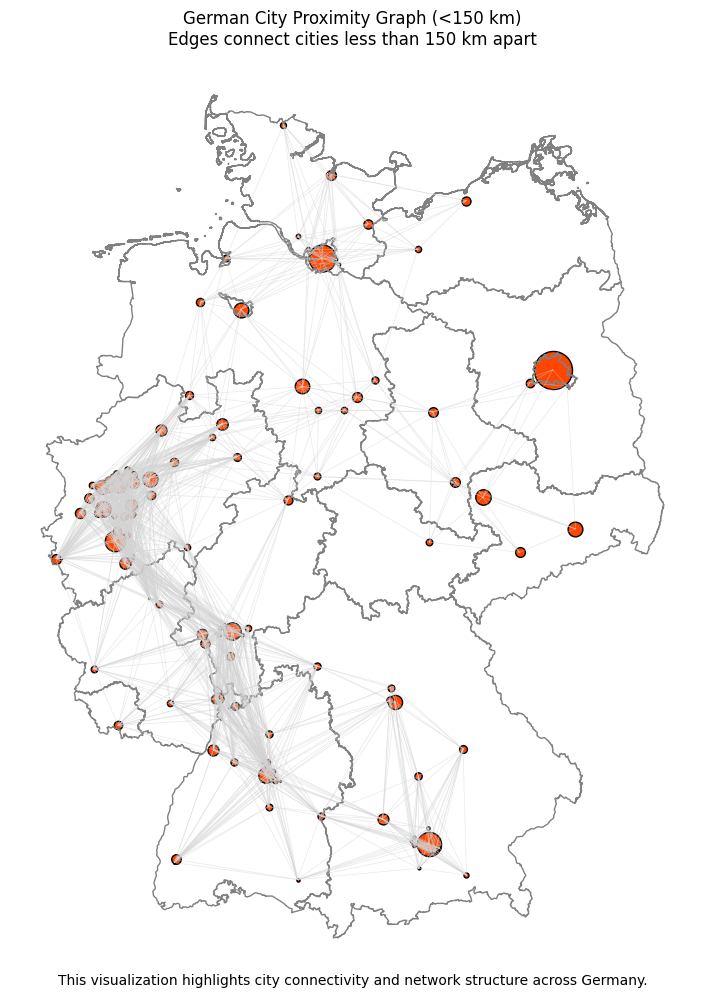

In [37]:
# Create position dict from node attributes
node_pos = {
    node: (float(attr["longitude"]), float(attr["latitude"]))
    for node, attr in G.nodes(data=True)
}

# Load Germany map
germany_states = gpd.read_file("data/gadm41_DEU_shp/gadm41_DEU_1.shp")
germany_states = germany_states.to_crs(epsg=4326)

# Plot
fig, ax = plt.subplots(figsize=(8, 10))
germany_states.boundary.plot(ax=ax, color="gray", linewidth=1)

# Draw edges
for u, v, data in G.edges(data=True):
    x = [node_pos[u][0], node_pos[v][0]]
    y = [node_pos[u][1], node_pos[v][1]]
    ax.plot(x, y, color="lightgray", linewidth=0.5, alpha=0.5)

# Draw nodes
for node, (lon, lat) in node_pos.items():
    pop = float(G.nodes[node]["population"])
    ax.scatter(lon, lat, s=pop/5000, color="orangered", edgecolors="black", alpha=1)

# Title
plt.title("German City Proximity Graph (<150 km)\nEdges connect cities less than 150 km apart", fontsize=12)
plt.axis("off")
plt.tight_layout()
# Add sub-caption below the graph
plt.figtext(0.5, 0.01, "This visualization highlights city connectivity and network structure across Germany.", 
            ha="center", fontsize=10)
plt.show()


The visualization shows the proximity network of 126 German cities on a map of Germany.

- Node size represents city population.
- Edges represent connections between cities below 150 km distance.

The graph highlights regional connectivity patterns and densely connected areas in the network.

## Initial Graph Analysis



The dataset was already cleaned before building the graph in **data_assembly.ipynb.** 
Missing population values were removed, duplicate coordinates were checked, and city pairs with 0 km distance were excluded to avoid division errors.

Since the graph was constructed directly from this cleaned dataset, no further preprocessing was needed at the graph level.


In [38]:
nx.number_connected_components(G)

1

The graph has only one connected component.  
This means that all cities are reachable from each other through the edges.  
The network is fully connected.


In [39]:
list(G.nodes())[:10]


['Berlin',
 'Stuttgart',
 'Munich',
 'Hamburg',
 'Cologne',
 'Frankfurt',
 'Düsseldorf',
 'Leipzig',
 'Dortmund',
 'Essen']

In [40]:
list(G.edges())[:10]



[('Berlin', 'Leipzig'),
 ('Berlin', 'Magdeburg'),
 ('Berlin', 'Potsdam'),
 ('Berlin', 'Eichwalde'),
 ('Stuttgart', 'Mannheim'),
 ('Stuttgart', 'Karlsruhe'),
 ('Stuttgart', 'Augsburg'),
 ('Stuttgart', 'Freiburg im Breisgau'),
 ('Stuttgart', 'Ludwigshafen'),
 ('Stuttgart', 'Heidelberg')]

In [41]:
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

degrees = [deg for _, deg in G.degree()]
print(f"Average degree: {sum(degrees)/len(degrees):.2f}")


Number of nodes: 126
Number of edges: 1646
Average degree: 26.13


This means that, on average, each city is connected to more than 26 other cities within a 150 km distance. The network is relatively dense and shows high connectivity between the cities in Germany.

In [42]:
G.degree()

DegreeView({'Berlin': 4, 'Stuttgart': 25, 'Munich': 16, 'Hamburg': 16, 'Cologne': 43, 'Frankfurt': 31, 'Düsseldorf': 38, 'Leipzig': 9, 'Dortmund': 39, 'Essen': 38, 'Bremen': 16, 'Dresden': 5, 'Hannover': 19, 'Nuremberg': 16, 'Duisburg': 38, 'Bochum': 38, 'Wuppertal': 38, 'Bielefeld': 33, 'Bonn': 46, 'Münster': 38, 'Mannheim': 33, 'Karlsruhe': 33, 'Augsburg': 29, 'Wiesbaden': 35, 'Mönchengladbach': 34, 'Gelsenkirchen': 38, 'Aachen': 33, 'Braunschweig': 15, 'Chemnitz': 5, 'Kiel': 12, 'Halle': 11, 'Magdeburg': 13, 'Freiburg im Breisgau': 13, 'Krefeld': 36, 'Mainz': 34, 'Lübeck': 12, 'Oberhausen': 38, 'Rostock': 6, 'Kassel': 20, 'Hagen': 39, 'Potsdam': 6, 'Saarbrücken': 17, 'Hamm': 38, 'Ludwigshafen': 33, 'Oldenburg': 13, 'Mülheim': 38, 'Osnabrück': 31, 'Leverkusen': 43, 'Heidelberg': 33, 'Darmstadt': 36, 'Solingen': 39, 'Regensburg': 18, 'Herne': 38, 'Paderborn': 33, 'Neuss': 35, 'Ingolstadt': 19, 'Fürth': 19, 'Ulm': 31, 'Heilbronn': 34, 'Pforzheim': 34, 'Würzburg': 31, 'Wolfsburg': 13, '

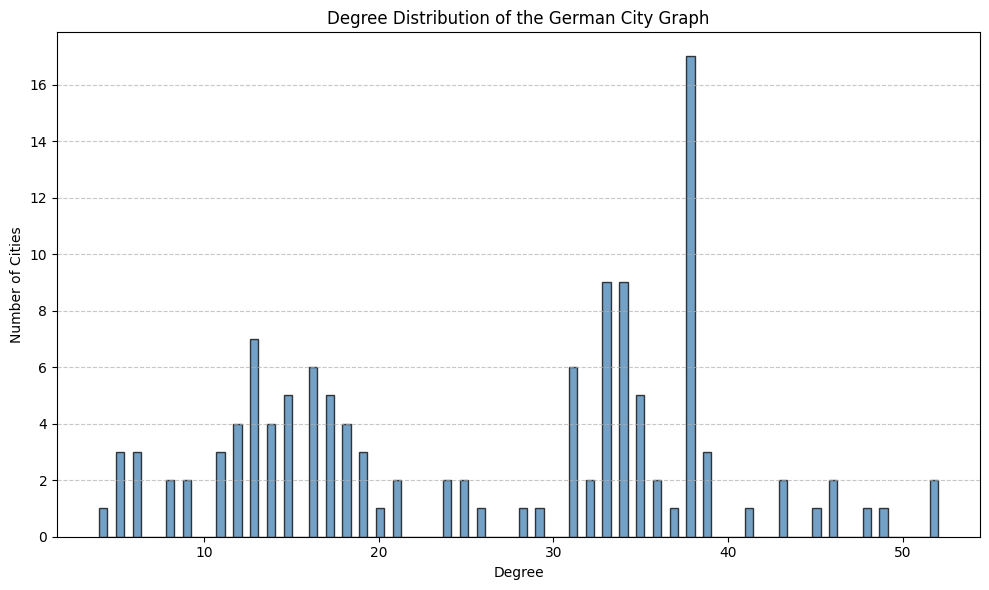

In [43]:
# Degree distribution histogram 

plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=100, color="steelblue", edgecolor="black", alpha=0.75)
plt.title("Degree Distribution of the German City Graph")
plt.xlabel("Degree")
plt.ylabel("Number of Cities")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Some cities are connected to more than 50 other cities, while others have fewer than 10 connections.

This suggests that certain cities act as highly connected hubs, while others are more isolated.

It would be interesting to further investigate which cities have the highest and lowest degrees, and how this relates to their location or population.

In [44]:
degrees = G.degree()

top_degrees = sorted(degrees, key=lambda x: x[1], reverse=True)

print("Top 10 Cities by Degree and Their Populations:")
for city, degree in top_degrees[:10]:
    population = G.nodes[city]["population"]
    print(f"{city}: Degree = {degree}, Population = {int(population):,}")


Top 10 Cities by Degree and Their Populations:
Koblenz: Degree = 52, Population = 115,268
Weißenthurm: Degree = 52, Population = 9,259
Siegen: Degree = 49, Population = 102,560
Siegburg: Degree = 48, Population = 42,049
Bonn: Degree = 46, Population = 336,465
Sankt Augustin: Degree = 46, Population = 56,369
Bergisch Gladbach: Degree = 45, Population = 112,712
Cologne: Degree = 43, Population = 1,084,831
Leverkusen: Degree = 43, Population = 165,748
Remscheid: Degree = 41, Population = 112,613


High-degree cities indicate strong geographic connectivity and potential as central hubs for EV charging stations. Especially cities like Cologne and Bonn, with both large populations and high degrees, can be key candidates for new station deployments

In [45]:
# Get nodes sorted by degree — lowest degrees first
bottom_degrees = sorted(degrees, key=lambda x: x[1])
print("\nBottom 10 Cities by Degree and Their Populations:")
for city, degree in bottom_degrees[:10]:
    population = G.nodes[city]["population"]
    print(f"{city}: Degree = {degree}, Population = {int(population):,}")



Bottom 10 Cities by Degree and Their Populations:
Berlin: Degree = 4, Population = 3,755,251
Dresden: Degree = 5, Population = 563,311
Chemnitz: Degree = 5, Population = 248,563
Eichwalde: Degree = 5, Population = 6,475
Rostock: Degree = 6, Population = 209,920
Potsdam: Degree = 6, Population = 185,750
Jena: Degree = 6, Population = 111,191
Erlangen: Degree = 8, Population = 116,562
Buckenhof: Degree = 8, Population = 3,157
Leipzig: Degree = 9, Population = 616,093


High-population cities with low degree

Although cities like Berlin (population ≈ 3.76 million, degree = 4) and Dresden (population = 563,311 , degree = 5)  have large populations, they are connected to only a few other cities in the network. 
This highlights a key structural limitation: some of the most populated urban areas are relatively isolated in the graph due to geographic distance.

## Graph Rewiring

For further analysis, rewired versions of the original graph were generated using `double_edge_swap` with different swap levels (10% to 150%).

These rewired graphs were later used to evaluate clustering stability and modularity under increasing randomness.

In [46]:
# Set flag: generate new graphs or load from file
generate_graphs =  False

# Compute swap percentages
num_edges = G.number_of_edges()

swap_percentages = [0, 10, 20, 30, 40, 50, 75, 100, 150]  # percent

# Loop over swap percentages
for percent in swap_percentages:
    swap_count = int(num_edges * (percent / 100))
    filename = f"data/swap_{percent}.graphml"

    if generate_graphs:
        # Make a copy of original graph
        G_swapped = G.copy()

        # Apply double_edge_swap
        nx.double_edge_swap(
            G_swapped,
            nswap=swap_count,
            max_tries=swap_count * 10,
            seed=42
        )

        # Save to GraphML
        nx.write_graphml(G_swapped, filename)
        print(f"Graph saved: {filename}")

    else:
        # Load existing graph
        G_swapped = nx.read_graphml(filename)
        print(f"Graph loaded: {filename}")


Graph loaded: data/swap_0.graphml
Graph loaded: data/swap_10.graphml
Graph loaded: data/swap_20.graphml
Graph loaded: data/swap_30.graphml
Graph loaded: data/swap_40.graphml
Graph loaded: data/swap_50.graphml
Graph loaded: data/swap_75.graphml
Graph loaded: data/swap_100.graphml
Graph loaded: data/swap_150.graphml


##  Graph Properties


In this step, different graph properties were computed for the original graph and for the rewired graphs created in the Graph Rewiring section. The goal is to observe how network topology changes as more edges are randomly rewired. The selected properties include basic measures (nodes, edges, density), connectivity measures (diameter, shortest path length), and clustering and assortativity. These properties help understand the structural effects of the edge swaps on the proximity network.


In [47]:
#  Define function to compute properties
def compute_graph_properties(G):
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)
    avg_clustering = nx.average_clustering(G)

    
    try:
        diameter = nx.diameter(G)
    except:
        diameter = "N/A"
        
    try:
      avg_shortest_path = nx.average_shortest_path_length(G)

    except:
        avg_shortest_path = "N/A"
        
    degree_assortativity = nx.degree_assortativity_coefficient(G)
    transitivity = nx.transitivity(G)
    num_components = nx.number_connected_components(G)
    largest_component_size = len(max(nx.connected_components(G), key=len))
    
    return {
        "Nodes": num_nodes,
        "Edges": num_edges,
        "Density": round(density, 4),
        "Avg Clustering": round(avg_clustering, 4),
        "Diameter": diameter,
        "Avg Shortest Path": avg_shortest_path if avg_shortest_path == "N/A" else round(avg_shortest_path, 4),
        "Assortativity": round(degree_assortativity, 4),
        "Transitivity": round(transitivity, 4),
        "Connected Components": num_components,
        "Largest Component Size": largest_component_size
    }

# Loop over all swap levels 
results = []

for percent in swap_percentages:
    
    if percent == 0:
        # Original graph
        G_current = G
        label = "Original"
    else:
        filename = f"data/swap_{percent}.graphml"
        G_current = nx.read_graphml(filename)
        label = f"{percent}% Swap"
    
    properties = compute_graph_properties(G_current)
    properties["Swap Level"] = label
    results.append(properties)

#  Create DataFrame
df_results = pd.DataFrame(results)

# Reorder columns
cols = ["Swap Level", "Nodes", "Edges", "Density", "Avg Clustering",
        "Diameter", "Avg Shortest Path", "Assortativity", "Transitivity",
        "Connected Components", "Largest Component Size"]

df_results = df_results[cols]
df_results


,Swap Level,Nodes,Edges,Density,Avg Clustering,Diameter,Avg Shortest Path,Assortativity,Transitivity,Connected Components,Largest Component Size
0,Original,126,1646,0.209,0.7765,7,2.9223,0.7057,0.7808,1,126
1,10% Swap,126,1646,0.209,0.4639,4,1.9294,0.4784,0.5188,1,126
2,20% Swap,126,1646,0.209,0.3470,3,1.8734,0.3533,0.4035,1,126
3,30% Swap,126,1646,0.209,0.3004,3,1.8580,0.2441,0.3500,1,126
4,40% Swap,126,1646,0.209,0.2927,3,1.8500,0.1650,0.3283,1,126
5,50% Swap,126,1646,0.209,0.2973,3,1.8513,0.0997,0.3156,1,126
6,75% Swap,126,1646,0.209,0.2980,3,1.8410,-0.0022,0.3037,1,126
7,100% Swap,126,1646,0.209,0.3087,3,1.8345,-0.0602,0.2956,1,126
8,150% Swap,126,1646,0.209,0.3028,3,1.8302,-0.0458,0.2988,1,126


- The diameter of the network decreases from 7 to 3, and the average shortest path also decreases (from 2.92 to 1.83). These changes mean that drivers would need fewer charging stops to travel between cities, which improves the overall accessibility and efficiency of the EV charging network.

- The clustering coefficient drops significantly (from 0.77 to approximately 0.30). This indicates that the original network had many triangle connections between cities, providing local redundancy. After the swaps, the number of such local patterns is reduced, making the network potentially less resilient for regional travel.

- The assortativity also decreases and even becomes negative (from 0.70 to negative values). In the original graph, some small and medium-sized cities had high degree values due to their geographic position. After the swaps, this structure becomes more random. For planning, it would be useful to maintain a good balance between hub cities and less connected cities.

- The network remains fully connected at all swap levels. No disconnected components appear, meaning that the network stays reliable for drivers and provides full coverage across the country.



## Centrality Analysis


This project aims to support the expansion of electric vehicle (EV) charging infrastructure in Germany. The goal is to improve network coverage, accessibility for EV users, and support future growth. 

 Several centrality measures — degree, closeness, betweenness, and eigenvector — will be calculated. These measures will help identify key cities for new charging stations. In the following section, we compare these centrality measures and discuss which are most useful for the project’s goals.


In [48]:
#  Define reusable plot function
def plot_centrality_networkx(G, centrality_dict, node_pos, title, top_n_labels=5, top_n_colored=20):
    # Node sizes based on population
    node_sizes = [float(G.nodes[node]['population']) / 5000 for node in G.nodes()]

    # Sort centralities
    sorted_nodes = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)
    top_nodes_colored = [node for node, _ in sorted_nodes[:top_n_colored]]
    top_nodes_labeled = [node for node, _ in sorted_nodes[:top_n_labels]]

    plt.figure(figsize=(12, 12))

    # Draw edges
    nx.draw_networkx_edges(G, node_pos, alpha=0.3, width=0.1)

    # Draw non-top nodes (gray)
    non_top_nodes = [node for node in G.nodes() if node not in top_nodes_colored]
    nx.draw_networkx_nodes(G, node_pos, nodelist=non_top_nodes,
                           node_size=[float(G.nodes[node]['population']) / 5000 for node in non_top_nodes],
                           node_color='lightgray', edgecolors='black', alpha=1)

    # Draw top-20 colored nodes
    nx.draw_networkx_nodes(G, node_pos, nodelist=top_nodes_colored,
                           node_size=[float(G.nodes[node]['population']) / 5000 for node in top_nodes_colored],
                           node_color='crimson', edgecolors='black', alpha=1)

    # Label only top 5
    nx.draw_networkx_labels(G, node_pos,
                            labels={node: node for node in top_nodes_labeled},
                            font_size=7, font_weight='bold')

    # Title and layout
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    # Add sub-caption below the graph
    
    plt.figtext(0.5, 0.01, 
                "Cities with the top 20 centrality scores are shown in red. Node size reflects population.The top 5 cities with the highest centrality scores are labeled with their names",
                ha="center", fontsize=10)
    plt.show()



Top 20 cities by Degree Centrality:
1. Koblenz: 0.4160
2. Weißenthurm: 0.4160
3. Siegen: 0.3920
4. Siegburg: 0.3840
5. Bonn: 0.3680
6. Sankt Augustin: 0.3680
7. Bergisch Gladbach: 0.3600
8. Cologne: 0.3440
9. Leverkusen: 0.3440
10. Remscheid: 0.3280
11. Dortmund: 0.3120
12. Hagen: 0.3120
13. Solingen: 0.3120
14. Düsseldorf: 0.3040
15. Essen: 0.3040
16. Duisburg: 0.3040
17. Bochum: 0.3040
18. Wuppertal: 0.3040
19. Münster: 0.3040
20. Gelsenkirchen: 0.3040


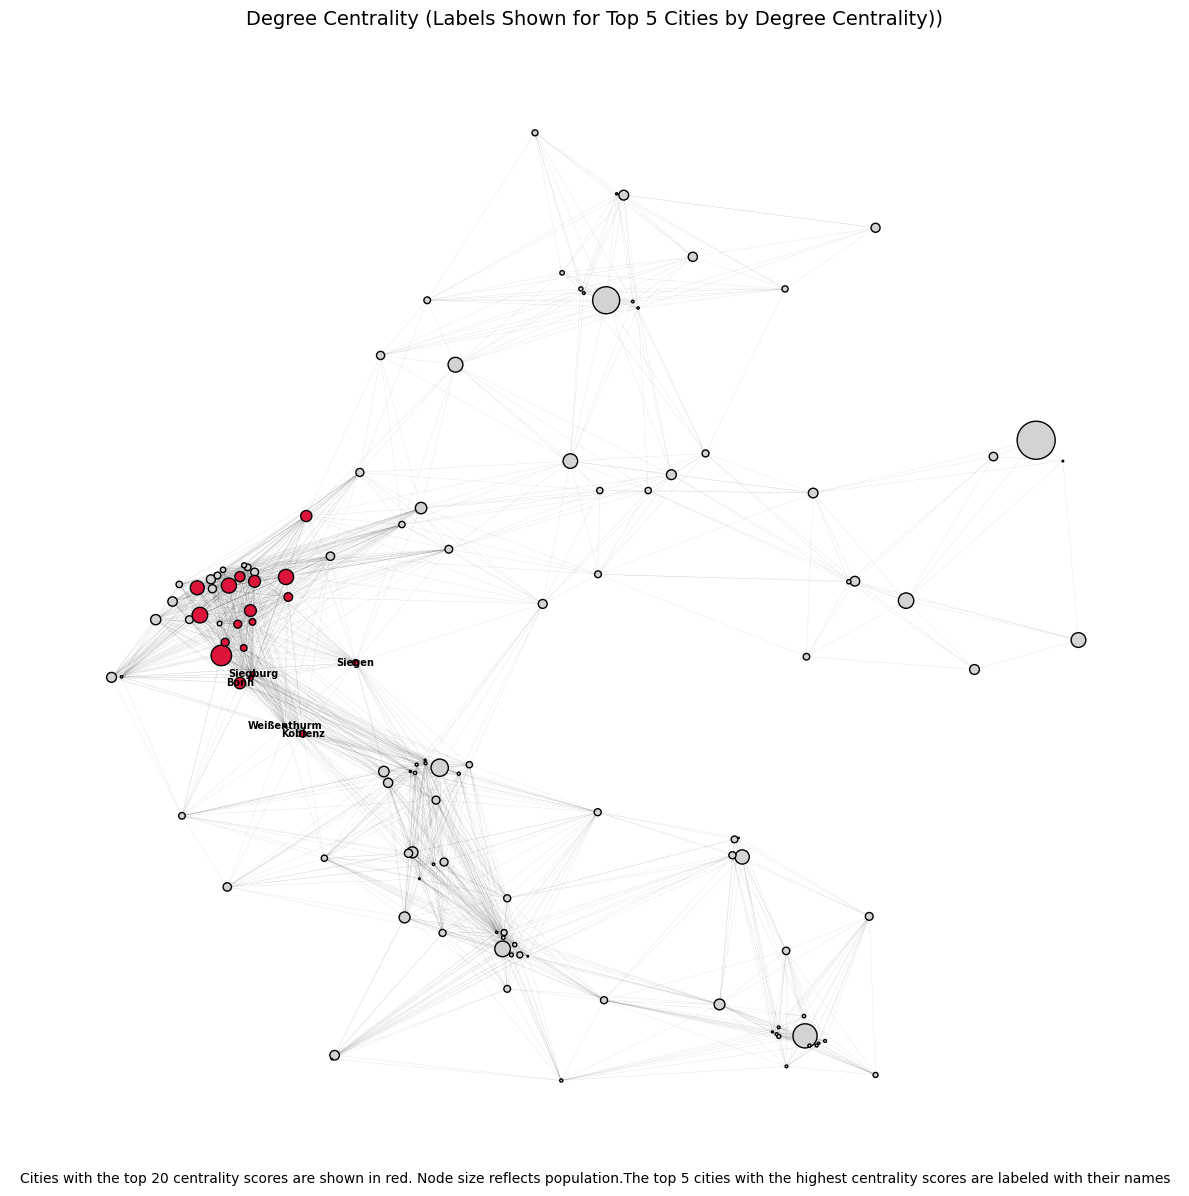

In [49]:
# Degree Centrality 
degree_centrality = nx.degree_centrality(G)

# Print top 20 cities
print("\nTop 20 cities by Degree Centrality:")
for i, (city, value) in enumerate(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"{i}. {city}: {value:.4f}")

# Plot
plot_centrality_networkx(G, degree_centrality, node_pos, "Degree Centrality (Labels Shown for Top 5 Cities by Degree Centrality))")




Degree centrality measures how many direct connections a node has in the network. In this case, it shows how many nearby cities (within 150 km) are directly connected to each city.

**Advantage:**  
Cities with high degree centrality are well connected to many neighboring cities. An EV charging station in such a city can serve a larger local area, giving good coverage for short-distance trips. 

**Limitation:**  
Degree centrality only counts local connections. It does not show if a city plays an important role in the whole network or in long-distance travel. Also, big cities like Berlin or Hamburg have low degree centrality because they are geographically more isolated in this network, even though they are important destinations for EV drivers. Therefore, degree centrality alone is not the best measure for deciding where to place new charging stations.



Top 20 cities by Betweenness Centrality:
1. Kassel: 0.1868
2. Ulm: 0.1102
3. Hannover: 0.0750
4. Koblenz: 0.0600
5. Weißenthurm: 0.0600
6. Göttingen: 0.0592
7. Braunschweig: 0.0527
8. Osnabrück: 0.0486
9. Obertshausen: 0.0464
10. Magdeburg: 0.0455
11. Augsburg: 0.0403
12. Gütersloh: 0.0391
13. Salzgitter: 0.0390
14. Hanau: 0.0381
15. Bad Soden am Taunus: 0.0376
16. Eschborn: 0.0365
17. Heilbronn: 0.0350
18. Steinbach am Taunus: 0.0347
19. Ludwigsburg: 0.0345
20. Asperg: 0.0345


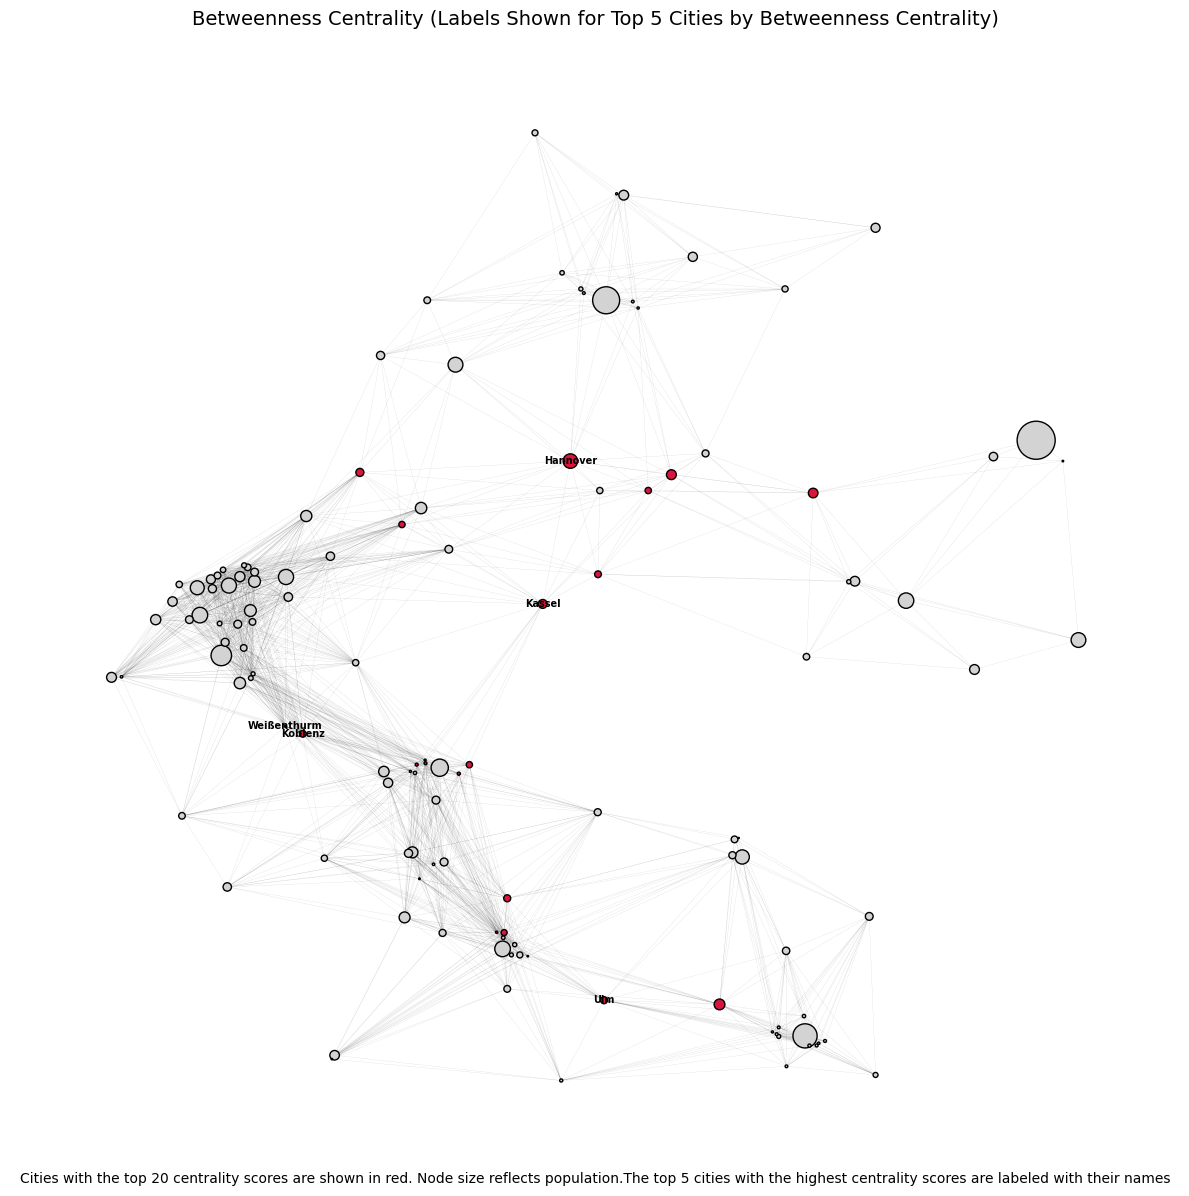

In [50]:
#  Betweenness Centrality 
betweenness_centrality = nx.betweenness_centrality(G)

# Print top 20 cities
print("\nTop 20 cities by Betweenness Centrality:")
for i, (city, value) in enumerate(sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"{i}. {city}: {value:.4f}")

# Plot with top 20 colored, top 5 labeled
plot_centrality_networkx(G, betweenness_centrality, node_pos, "Betweenness Centrality (Labels Shown for Top 5 Cities by Betweenness Centrality)", top_n_labels=5, top_n_colored=20)


- Betweenness centrality measures how often a node appears on the shortest paths between other nodes in the network. In this project, it shows which cities act as important bridges between different regions of the EV charging network. A city with high betweenness centrality is frequently used as an intermediate point when drivers travel between distant cities. This means the city plays a key role in keeping the network connected and supporting long-distance EV travel.
  
- Cities with high betweenness centrality connect different parts of the country. Placing an EV charging station in such a city helps reduce network gaps and improves overall accessibility for drivers on cross-regional trips. These cities often act as “bridges” or “transfer points” in the transportation network. If a key bridge city does not have a charging station, EV drivers face difficulties completing long-distance routes. Installing stations in these cities can increase network robustness and prevent the problem of disconnected areas.

In this project’s results, cities such as **Kassel, Ulm, and Hannover** have the highest betweenness centrality. By placing new EV charging stations in such locations, the network coverage can be strengthened, and drivers can travel more easily between northern, southern, eastern, and western regions. In this way, betweenness centrality provides very useful guidance for improving the practical connectivity of the EV charging network.




Top 20 cities by Closeness Centrality:
1. Bad Soden am Taunus: 0.4664
2. Eschborn: 0.4647
3. Steinbach am Taunus: 0.4647
4. Koblenz: 0.4613
5. Obertshausen: 0.4613
6. Weißenthurm: 0.4613
7. Frankfurt: 0.4596
8. Hanau: 0.4596
9. Siegen: 0.4545
10. Siegburg: 0.4529
11. Bonn: 0.4448
12. Sankt Augustin: 0.4448
13. Kassel: 0.4401
14. Bergisch Gladbach: 0.4401
15. Remscheid: 0.4401
16. Leverkusen: 0.4371
17. Solingen: 0.4371
18. Cologne: 0.4355
19. Wiesbaden: 0.4296
20. Hamm: 0.4296


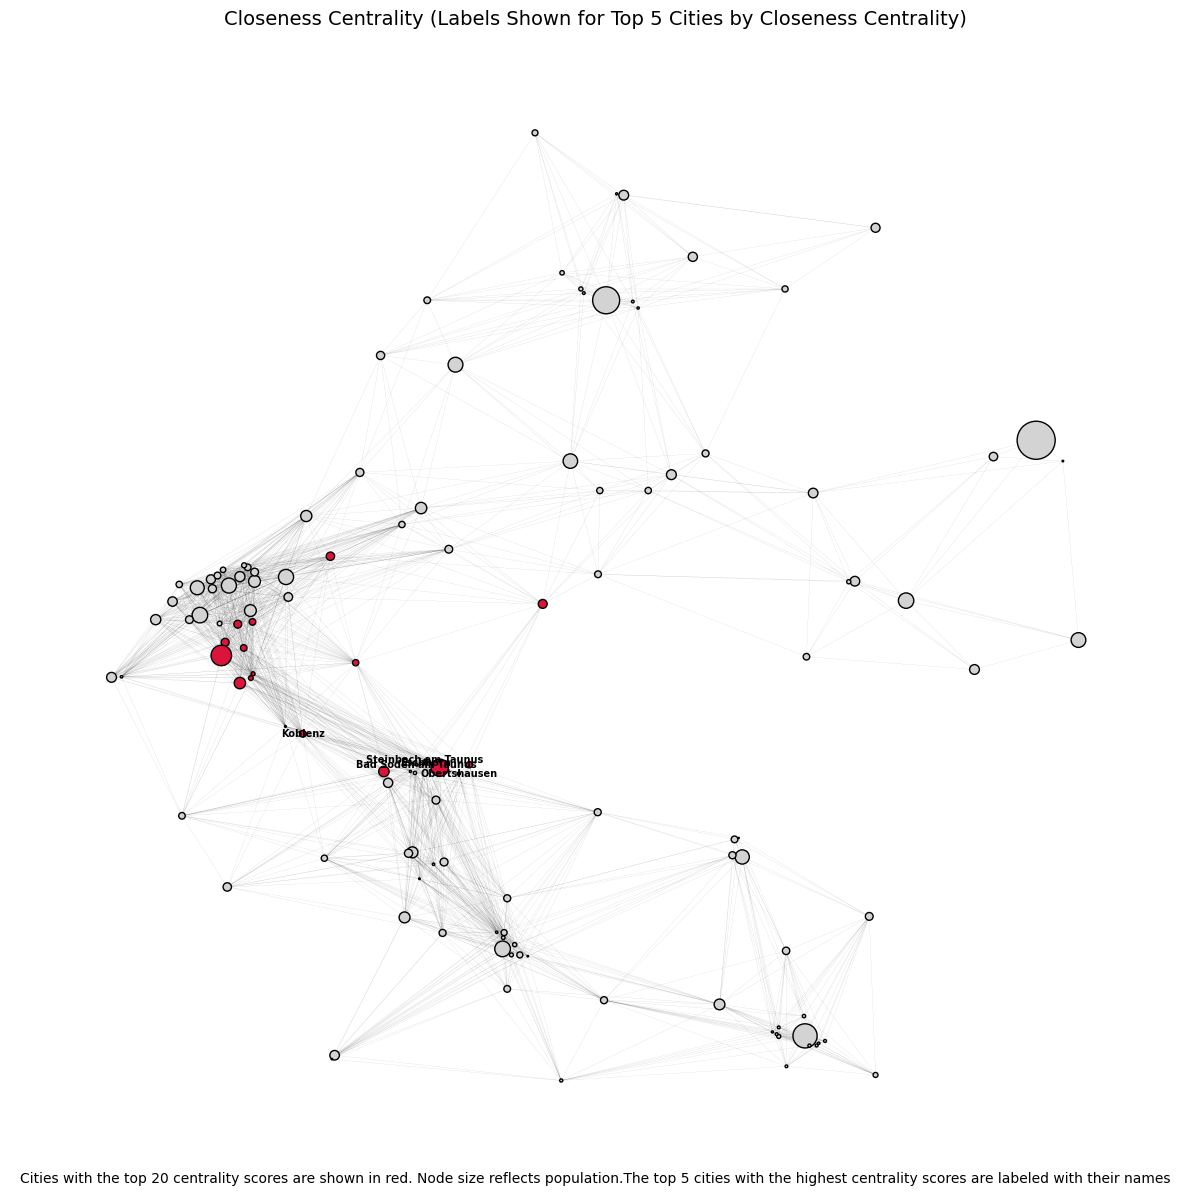

In [51]:
# Closeness Centrality
closeness_centrality = nx.closeness_centrality(G)

# Print top 20 cities
print("\nTop 20 cities by Closeness Centrality:")
for i, (city, value) in enumerate(sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"{i}. {city}: {value:.4f}")

# Plot
plot_centrality_networkx(G, closeness_centrality, node_pos, "Closeness Centrality (Labels Shown for Top 5 Cities by Closeness Centrality)")


- The Top 20 cities by closeness centrality include **Bad Soden am Taunus, Eschborn, Steinbach am Taunus, Koblenz, and Weißenthurm**. Their centrality scores show that they can be reached quickly from many other cities, with shorter average travel distances across the network.

- Installing EV charging stations in these locations would provide high accessibility for drivers, as many routes can reach these stations with minimal detours. This would help optimize the user experience and support a well-balanced charging infrastructure across the network.


Top 20 cities by Eigenvector Centrality:
1. Siegen: 0.1737
2. Siegburg: 0.1716
3. Koblenz: 0.1708
4. Weißenthurm: 0.1708
5. Bergisch Gladbach: 0.1662
6. Bonn: 0.1653
7. Sankt Augustin: 0.1653
8. Leverkusen: 0.1624
9. Cologne: 0.1615
10. Remscheid: 0.1597
11. Solingen: 0.1553
12. Dortmund: 0.1543
13. Hagen: 0.1543
14. Düsseldorf: 0.1531
15. Essen: 0.1531
16. Duisburg: 0.1531
17. Bochum: 0.1531
18. Wuppertal: 0.1531
19. Gelsenkirchen: 0.1531
20. Oberhausen: 0.1531


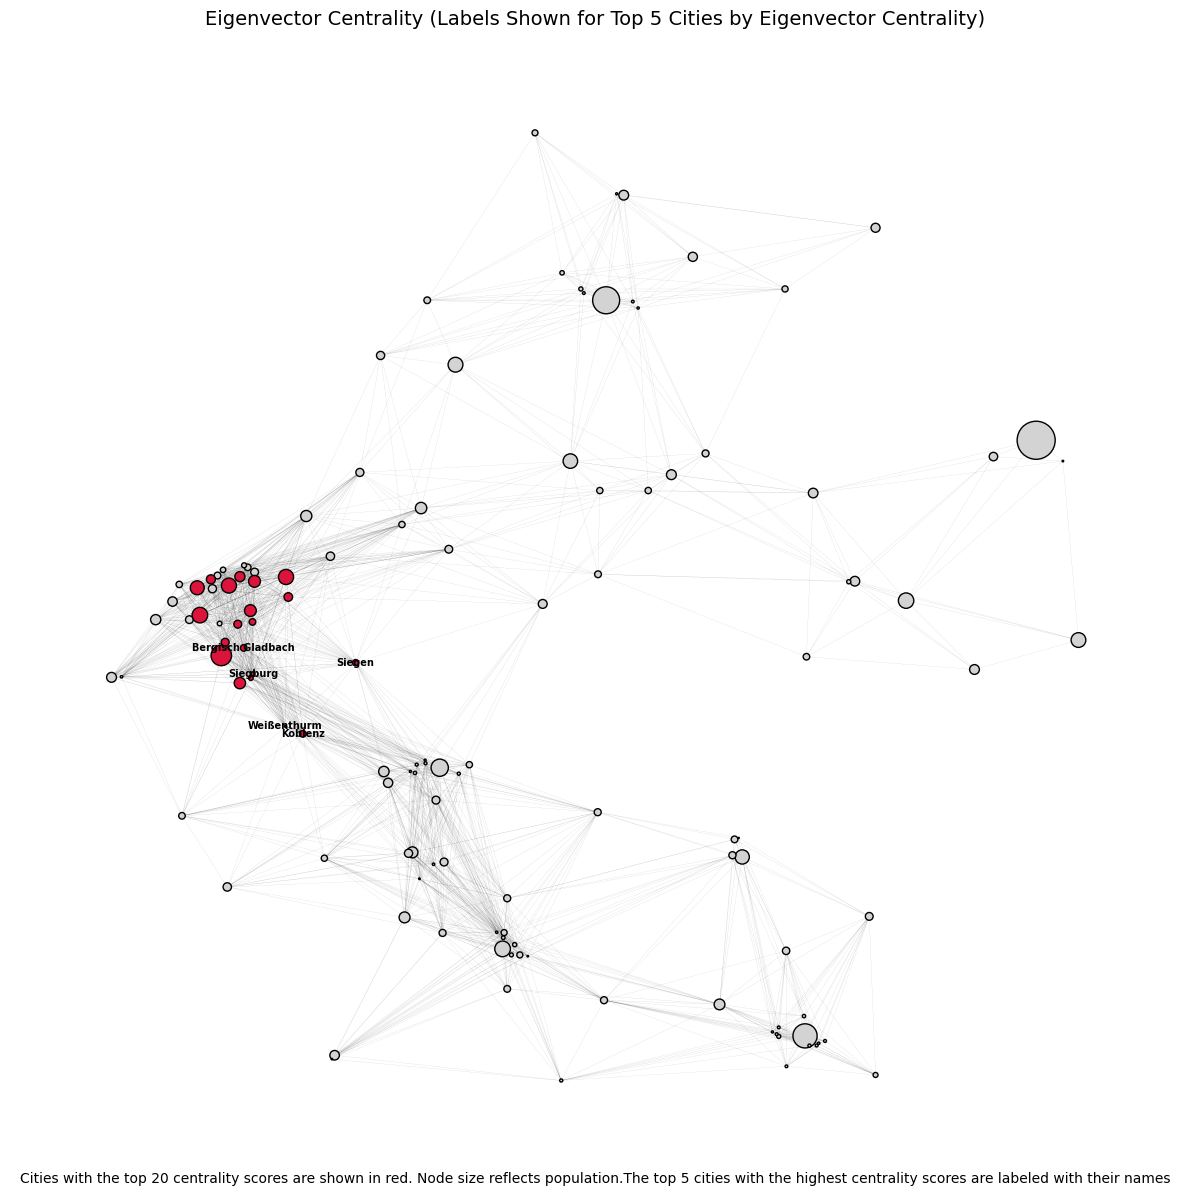

In [52]:
# Eigenvector Centrality 
eigenvector_centrality = nx.eigenvector_centrality(G)

# Print top 20 cities
print("\nTop 20 cities by Eigenvector Centrality:")
for i, (city, value) in enumerate(sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"{i}. {city}: {value:.4f}")

# Plot
plot_centrality_networkx(G, eigenvector_centrality, node_pos, "Eigenvector Centrality (Labels Shown for Top 5 Cities by Eigenvector Centrality)")


- The Top 20 cities by eigenvector centrality include **Siegen, Siegburg, Koblenz, Weißenthurm, Bonn, Cologne** and other cities in densely connected regions of Germany. 
 - High eigenvector centrality indicates that these cities are not only well connected themselves but are also linked to other important and well-connected cities in the network.

- In this project, such cities represent strong regional hubs in the EV charging network. Adding or reinforcing EV charging stations in these hubs would support existing demand and encourage further growth in EV adoption. For example, stations in Cologne or Bonn would serve the wider network, as these cities influence many surrounding areas.

**Comparison of Cities in Top 20 of All Centrality Metrics**

In [53]:
def get_ranking_dict(centrality_dict, top_n=None):
    sorted_cities = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)
    if top_n is not None:
        sorted_cities = sorted_cities[:top_n]
    return {city: (rank+1, value) for rank, (city, value) in enumerate(sorted_cities)}


In [54]:
# Prepare ranking dictionaries 

degree_rank = get_ranking_dict(degree_centrality, top_n=20)
betweenness_rank = get_ranking_dict(betweenness_centrality, top_n=20)
closeness_rank = get_ranking_dict(closeness_centrality, top_n=20)
eigenvector_rank = get_ranking_dict(eigenvector_centrality, top_n=20)

# Find common cities present in ALL 4 measures

common_cities = set(degree_rank.keys()) & set(betweenness_rank.keys()) & set(closeness_rank.keys()) & set(eigenvector_rank.keys())

# Build dataframe 

rows = []
for city in sorted(common_cities):
    row = {
        'City': city,
        'Degree Rank': degree_rank[city][0],
        'Degree Value': degree_rank[city][1],
        'Betweenness Rank': betweenness_rank[city][0],
        'Betweenness Value': betweenness_rank[city][1],
        'Closeness Rank': closeness_rank[city][0],
        'Closeness Value': closeness_rank[city][1],
        'Eigenvector Rank': eigenvector_rank[city][0],
        'Eigenvector Value': eigenvector_rank[city][1],
    }
    rows.append(row)

df_common_all4 = pd.DataFrame(rows)

# --- Display ---

pd.set_option('display.max_rows', None)
display(df_common_all4)


,City,Degree Rank,Degree Value,Betweenness Rank,Betweenness Value,Closeness Rank,Closeness Value,Eigenvector Rank,Eigenvector Value
0,Koblenz,1,0.416,4,0.060037,4,0.461255,3,0.170845
1,Weißenthurm,2,0.416,5,0.060037,6,0.461255,4,0.170845


- Only **Koblenz** and **Weißenthurm** appear in the Top 20 of all four centrality measures.
- These cities show the highest local connectivity, strategic bridging roles, and central positions in the network.
- They are very good candidates for new EV charging stations to improve both regional access and long-distance connectivity

In [55]:

# Prepare ranking dictionaries 
degree_rank = get_ranking_dict(degree_centrality)
betweenness_rank = get_ranking_dict(betweenness_centrality)
closeness_rank = get_ranking_dict(closeness_centrality)
eigenvector_rank = get_ranking_dict(eigenvector_centrality)

# Take Top 10 Betweenness cities 

top10_betweenness_cities = [city for city, _ in sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]]

# --- Build dataframe ---

rows = []
for city in top10_betweenness_cities:
    row = {
        'City': city,
        'Betweenness Rank': betweenness_rank[city][0],
        'Betweenness Value': betweenness_rank[city][1],
        'Closeness Rank': closeness_rank[city][0],
        'Closeness Value': closeness_rank[city][1],
        'Degree Rank': degree_rank[city][0],
        'Degree Value': degree_rank[city][1],
        'Eigenvector Rank': eigenvector_rank[city][0],
        'Eigenvector Value': eigenvector_rank[city][1],
    }
    rows.append(row)

df_top10_betw_all = pd.DataFrame(rows)

# --- Display ---

pd.set_option('display.max_rows', None)
display(df_top10_betw_all)


,City,Betweenness Rank,Betweenness Value,Closeness Rank,Closeness Value,Degree Rank,Degree Value,Eigenvector Rank,Eigenvector Value
0,Kassel,1,0.186786,13,0.440141,74,0.160,58,0.046685
1,Ulm,2,0.110191,77,0.344353,61,0.248,75,0.016135
2,Hannover,3,0.075010,65,0.382263,75,0.152,72,0.019558
3,Koblenz,4,0.060037,4,0.461255,1,0.416,3,0.170845
4,Weißenthurm,5,0.060037,6,0.461255,2,0.416,4,0.170845
5,Göttingen,6,0.059188,70,0.373134,98,0.112,74,0.016164
6,Braunschweig,7,0.052719,69,0.373134,93,0.120,83,0.009503
7,Osnabrück,8,0.048647,62,0.389408,60,0.248,39,0.102125
8,Obertshausen,9,0.046415,5,0.461255,58,0.256,50,0.067189
9,Magdeburg,10,0.045512,94,0.294811,102,0.104,92,0.002117


**Summary of Insights:**

- The centrality analysis highlights different strategic roles among these top cities.

- **Kassel, Ulm, and Hannover** act as major bridges in the network (high betweenness), which is crucial for connecting distant regions.

- **Koblenz and Weißenthurm** rank highest  in all four centrality measures. They are not only central and well connected (closeness and degree), but also influential in the network (eigenvector) and important for linking different regions (betweenness).  

- **Obertshausen** shows high closeness but moderate degree. It can serve as a central connector in its region.

- **Osnabrück** emerges as an influential regional hub with many connections and links to other key cities (moderate-high degree and eigenvector).

- **Göttingen, Braunschweig, and Magdeburg** have more specialized bridging roles — they are not the most connected overall, but their betweenness shows they help link certain parts of the country.

These insights can guide the EV charging station operator to prioritize cities that maximize network connectivity and coverage, ensuring efficient travel and charging access across Germany’s regions.

**Determining the Most Suitable Centrality Measure for Project Goals**

Considering the main goals of the project — to increase network coverage and improve accessibility — it is essential to connect all parts of the network and avoid isolated regions. From this perspective, **betweenness centrality is the most informative measure**, because it identifies cities that act as critical bridges between different parts of the network. Installing EV charging stations in these cities will most effectively expand coverage and support long-distance travel by providing key charging points on major routes.

Closeness centrality is also highly important in this project, as it identifies cities that offer short and easy access to other parts of the network. Placing stations in cities with high closeness centrality will improve accessibility for many drivers by reducing travel distances and ensuring a more balanced and user-friendly charging infrastructure.

By combining both measures — targeting cities that are both important bridges and geographically central — the project can achieve its goals of building a connected, accessible, and reliable EV charging network across the country.

##  Community Discovery

In [56]:
#  Louvain community detection on original graph 

def compute_louvain_partition(G, random_state=42):
    partition = community_louvain.best_partition(G, random_state=random_state)
    return partition


In [57]:
# Girvan-Newman community detection on original graph  

def compute_best_girvannewman_partition(G, max_steps=15):
    comp = girvan_newman(G)
    
    best_partition = None
    best_modularity = -1
    
    for i, communities in enumerate(comp):
        # convert to partition dict
        partition = {}
        for j, comm in enumerate(communities):
            for node in comm:
                partition[node] = j
                
        mod = compute_modularity(G, partition)
        
        if mod > best_modularity:
            best_modularity = mod
            best_partition = partition
        
        # stop after too many steps (to avoid very long run)
        if len(communities) > max_steps:
            break
    
    return best_partition, best_modularity


In [58]:
#  Compute modularity 

def compute_modularity(G, partition):
    comm_dict = {}
    for node, comm_id in partition.items():
        if comm_id not in comm_dict:
            comm_dict[comm_id] = set()
        comm_dict[comm_id].add(node)
    community_list = list(comm_dict.values())
    
    return nx.algorithms.community.modularity(G, community_list)


In [59]:
# Louvain partition on original graph 

louvain_partition_orig = compute_louvain_partition(G, random_state=42)
mod_louvain_orig = compute_modularity(G, louvain_partition_orig)

print(f"Louvain (original graph): {len(set(louvain_partition_orig.values()))} communities, modularity = {mod_louvain_orig:.4f}")

# Girvan-Newman partition on original graph 

girvan_partition_orig, mod_girvan_orig = compute_best_girvannewman_partition(G, max_steps=15)

print(f"Girvan-Newman (original graph): {len(set(girvan_partition_orig.values()))} communities, modularity = {mod_girvan_orig:.4f}")


Louvain (original graph): 7 communities, modularity = 0.6464
Girvan-Newman (original graph): 5 communities, modularity = 0.6314


- Both Louvain and Girvan-Newman algorithms detected clear community structure in the original graph.
- Louvain produced 7 communities with a modularity of 0.6464, while Girvan-Newman produced 5 communities with a modularity of 0.6314.
- The modularity values of both algorithms are high (> 0.6), which indicates strong community structure

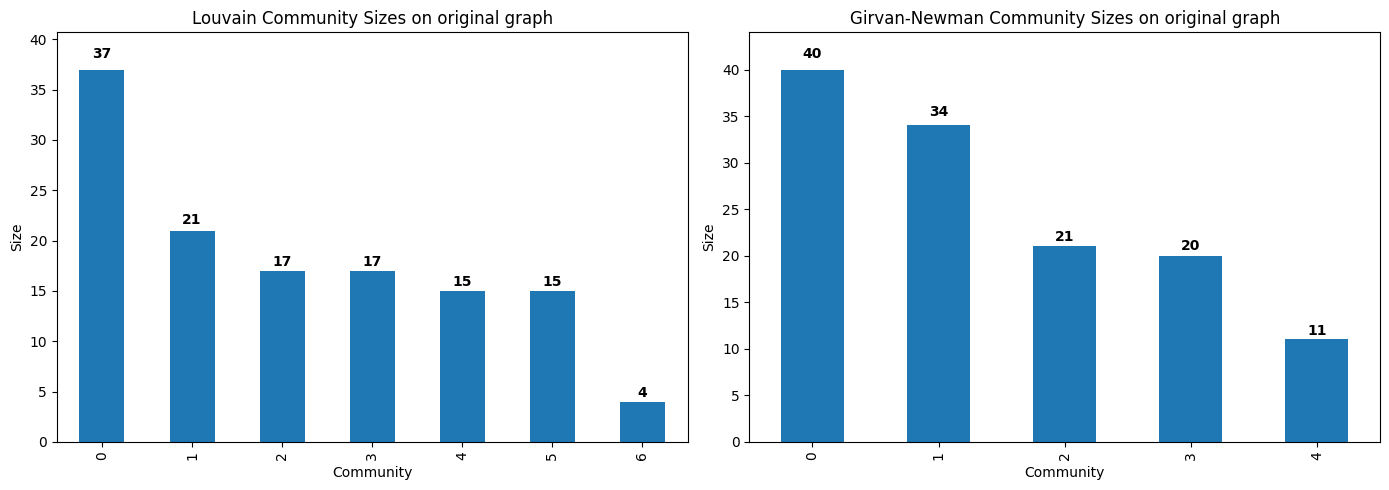

In [60]:
# Community size plots side-by-side 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # to make the plots side by side

# Louvain 
ax1 = axes[0]
louvain_sizes = pd.Series(list(pd.Series(louvain_partition_orig).value_counts()))
louvain_sizes.plot(kind='bar', ax=ax1, title='Louvain Community Sizes on original graph')
ax1.set_xlabel('Community')
ax1.set_ylabel('Size')
ax1.set_ylim(0, louvain_sizes.max() * 1.1)
for i, v in enumerate(louvain_sizes):
    offset = max(0.5, v * 0.03)
    ax1.text(i, v + offset, str(v), ha='center', fontweight='bold')

# Girvan-Newman 
ax2 = axes[1]
girvan_sizes = pd.Series(list(pd.Series(girvan_partition_orig).value_counts()))
girvan_sizes.plot(kind='bar', ax=ax2, title='Girvan-Newman Community Sizes on original graph')
ax2.set_xlabel('Community')
ax2.set_ylabel('Size')
ax2.set_ylim(0, girvan_sizes.max() * 1.1)
for i, v in enumerate(girvan_sizes):
    offset = max(0.5, v * 0.03)
    ax2.text(i, v + offset, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


- Louvain produced 7 strong local communities (modularity = 0.6464) on the original graph (sizes: 37, 21, 17, 17, 15, 15, 4), including one very small community (4 nodes).

- Girvan-Newman produced strong but fewer and broader communities (modularity = 0.6314, 5 communities: 40, 34, 21, 20, 11), without very small clusters, on the original graph.

- For the EV charging expansion, Louvain’s partition can guide targeted improvements in smaller regions, while Girvan-Newman’s broader communities can help plan large-scale regional hubs.

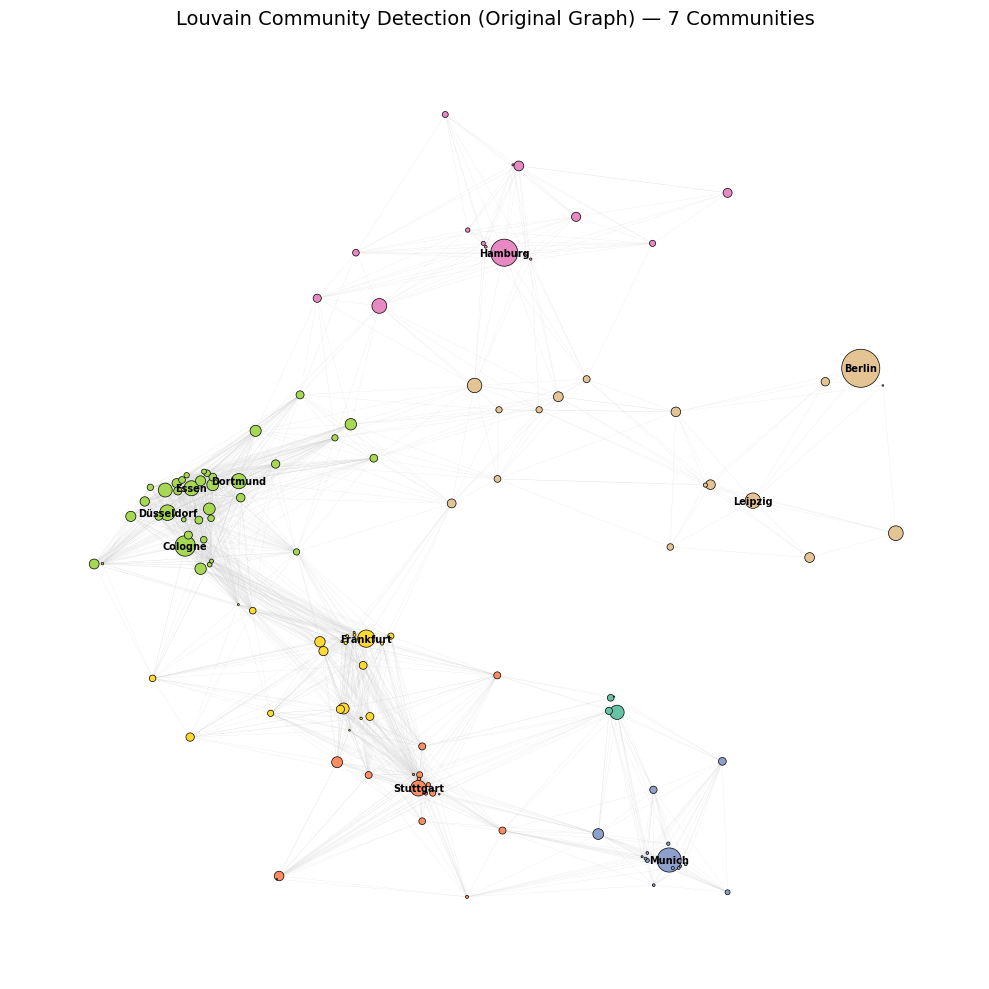

In [61]:
# Get number of communities
num_comms = len(set(louvain_partition_orig.values()))
cmap = plt.colormaps['Set2'] 

# Node colors based on community ID
node_colors = [cmap(louvain_partition_orig[node]) for node in G.nodes()]

# Draw network with black-edged nodes
plt.figure(figsize=(10, 10))

# Draw edges
nx.draw_networkx_edges(G, pos=node_pos, edge_color='lightgray', width=0.1)

# Draw nodes with black edge
nx.draw_networkx_nodes(
    G,
    pos=node_pos,
    node_color=node_colors,
    node_size=[float(G.nodes[n]['population'])/5000 for n in G.nodes()],
    edgecolors='black',  # siyah çerçeve
    linewidths=0.5,
    alpha=1
)


# label top 10 cities by population
top_cities = sorted(G.nodes(data=True), key=lambda x: float(x[1]["population"]), reverse=True)[:10]
for node, attr in top_cities:
    x, y = node_pos[node]
    plt.text(x, y, node, fontsize=7, fontweight='bold', ha='center', va='center')

plt.title(f"Louvain Community Detection (Original Graph) — {num_comms} Communities", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


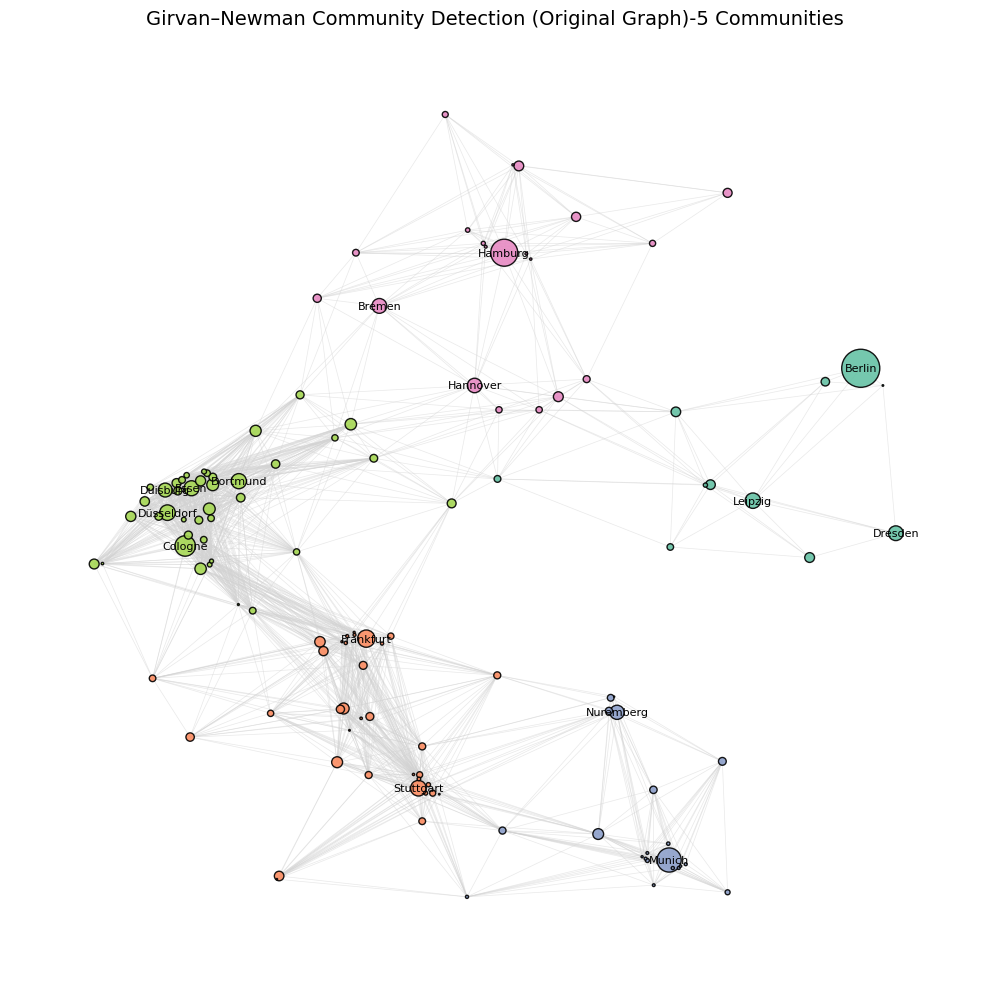

In [62]:
num_comms = len(set(girvan_partition_orig.values()))
cmap = plt.colormaps['Set2']

node_colors = [cmap(girvan_partition_orig[node] % cmap.N) for node in G.nodes()]

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_edges(G, pos=node_pos, ax=ax, edge_color='lightgray', width=0.5, alpha=0.5)
nx.draw_networkx_nodes(G, pos=node_pos, node_color=node_colors,
                       node_size=[G.nodes[n]['population'] / 5000 for n in G.nodes()],
                       edgecolors='black', alpha=0.9)

# Label only big cities
for node, (x, y) in node_pos.items():
    if G.nodes[node]['population'] > 500000:
        ax.text(x, y, node, fontsize=8, ha='center', va='center')

ax.set_title("Girvan–Newman Community Detection (Original Graph)-5 Communities", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


In [63]:
# Community detection on rewired graphs 

results = []

for percent in swap_percentages:
    filename = f"data/swap_{percent}.graphml"
    G_current = nx.read_graphml(filename)
    print(f"Graph loaded: {filename}")

    # Louvain 
    louvain_partition = compute_louvain_partition(G_current, random_state=42)
    louvain_modularity = compute_modularity(G_current, louvain_partition)

    # Girvan-Newman 
    girvan_partition, girvan_modularity = compute_best_girvannewman_partition(G_current, max_steps=15)

    # Save results
    results.append({
        'Swap %': percent,
        'Louvain Modularity': louvain_modularity,
        'Girvan-Newman Modularity': girvan_modularity,
        'Louvain #Communities': len(set(louvain_partition.values())),
        'Girvan-Newman #Communities': len(set(girvan_partition.values()))
    })

# Create DataFrame
df_results = pd.DataFrame(results)
display(df_results)


Graph loaded: data/swap_0.graphml
Graph loaded: data/swap_10.graphml
Graph loaded: data/swap_20.graphml
Graph loaded: data/swap_30.graphml
Graph loaded: data/swap_40.graphml
Graph loaded: data/swap_50.graphml
Graph loaded: data/swap_75.graphml
Graph loaded: data/swap_100.graphml
Graph loaded: data/swap_150.graphml


,Swap %,Louvain Modularity,Girvan-Newman Modularity,Louvain #Communities,Girvan-Newman #Communities
0,0,0.646387,0.631447,7,5
1,10,0.364583,0.010808,9,14
2,20,0.271640,0.000064,7,16
3,30,0.222141,0.000781,8,16
4,40,0.202195,0.001366,8,13
5,50,0.187840,0.000830,6,14
6,75,0.169907,0.001030,6,13
7,100,0.151791,0.002707,7,14
8,150,0.139241,0.001037,5,16


- Both algorithms detect strong community structure on the original graph (0% swaps):

 Louvain modularity Q = 0.646, 7 communities

  Girvan–Newman Q = 0.631, 5 communities

- As rewiring increases, modularity declines for both methods:

 Louvain: modularity drops gradually - more robust to noise

 Girvan–Newman: modularity collapses sharply after only 10% swap - very sensitive

- Community counts:

Louvain stays stable (5–9 communities) across all swap % - avoids over-fragmentation

Girvan–Newman jumps quickly (from 5 to 14–16 communities) - over-fragments under noise

- Interpretation:

Louvain provides more consistent community detection under network rewiring

Girvan–Newman highly sensitive to small changes, quickly loses meaningful structure



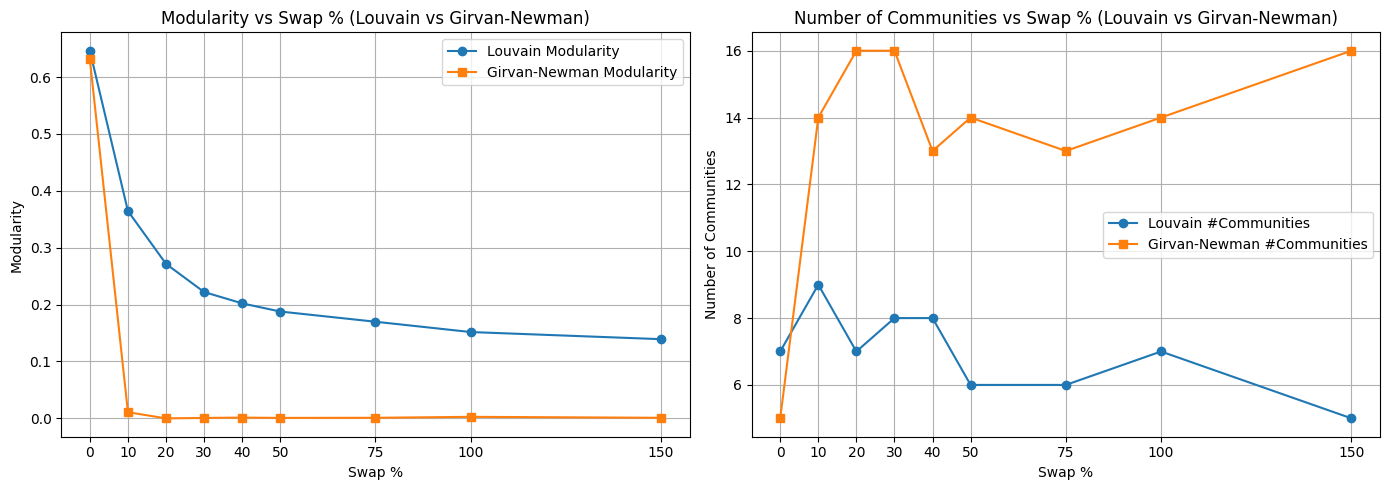

In [64]:
#  Plot modularity and number of communities vs swap % (side by side) 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # to make plots side by side

# --- Modularity plot ---
ax1 = axes[0]
ax1.plot(df_results['Swap %'], df_results['Louvain Modularity'], marker='o', label='Louvain Modularity')
ax1.plot(df_results['Swap %'], df_results['Girvan-Newman Modularity'], marker='s', label='Girvan-Newman Modularity')

ax1.set_xlabel('Swap %')
ax1.set_ylabel('Modularity')
ax1.set_title('Modularity vs Swap % (Louvain vs Girvan-Newman)')
ax1.legend()
ax1.grid(True)
ax1.set_xticks(swap_percentages)

# --- Number of Communities plot ---
ax2 = axes[1]
ax2.plot(df_results['Swap %'], df_results['Louvain #Communities'], marker='o', label='Louvain #Communities')
ax2.plot(df_results['Swap %'], df_results['Girvan-Newman #Communities'], marker='s', label='Girvan-Newman #Communities')

ax2.set_xlabel('Swap %')
ax2.set_ylabel('Number of Communities')
ax2.set_title('Number of Communities vs Swap % (Louvain vs Girvan-Newman)')
ax2.legend()
ax2.grid(True)
ax2.set_xticks(swap_percentages)

plt.tight_layout()
plt.show()


- Louvain modularity curve:

Starts high  Q ≈ 0.64 at 0% swap (original graph)

Gradually declines  Q ≈ 0.36 at 10%, Q ≈ 0.15 at 100%

 Shows gradual weakening of community structure with randomness

- Girvan–Newman modularity curve:

Drops rapidly to near zero after only 10% swap and continues to stay near zero for all swap percentages.

 Shows abrupt loss of community detection



**Stability of Original Community Partitions on Rewired Graphs**

We used the original partitions computed on the unmodified graph (**7 communities for Louvain, 5 communities for Girvan–Newman**) and calculated their modularity on the rewired graphs.

This shows how well the original community structure holds as the network becomes more randomized.

In [65]:
# Stability test of original partitions 

stability_results = []

# These two partitions were already computed above:
# louvain_partition_orig
# girvan_partition_orig

# Number of communities in the original partitions:
num_louvain_communities = len(set(louvain_partition_orig.values()))
num_girvan_communities = len(set(girvan_partition_orig.values()))

for percent in swap_percentages:
    filename = f"data/swap_{percent}.graphml"
    G_current = nx.read_graphml(filename)
    print(f"Graph loaded: {filename}")

    # Modularity of original Louvain partition on the current graph
    mod_louvain_orig_partition = compute_modularity(G_current, louvain_partition_orig)

    # Modularity of original Girvan-Newman partition on the current graph
    mod_girvan_orig_partition = compute_modularity(G_current, girvan_partition_orig)

    # Save results
    stability_results.append({
        'Swap %': percent,
        'Louvain (orig partition) modularity': mod_louvain_orig_partition,
        'Girvan-Newman (orig partition) modularity': mod_girvan_orig_partition,
        'Louvain #Communities': num_louvain_communities,
        'Girvan-Newman #Communities': num_girvan_communities
    })

# Create DataFrame
df_stability = pd.DataFrame(stability_results)
display(df_stability)


Graph loaded: data/swap_0.graphml
Graph loaded: data/swap_10.graphml
Graph loaded: data/swap_20.graphml
Graph loaded: data/swap_30.graphml
Graph loaded: data/swap_40.graphml
Graph loaded: data/swap_50.graphml
Graph loaded: data/swap_75.graphml
Graph loaded: data/swap_100.graphml
Graph loaded: data/swap_150.graphml


,Swap %,Louvain (orig partition) modularity,Girvan-Newman (orig partition) modularity,Louvain #Communities,Girvan-Newman #Communities
0,0,0.646387,0.631447,7,5
1,10,-0.096754,-0.131329,7,5
2,20,-0.133509,-0.163623,7,5
3,30,-0.132326,-0.160688,7,5
4,40,-0.110810,-0.140271,7,5
5,50,-0.105908,-0.140893,7,5
6,75,-0.077484,-0.097446,7,5
7,100,-0.049319,-0.061916,7,5
8,150,-0.023019,-0.027473,7,5


- At 0% swap (original graph), both Louvain and Girvan–Newman original partitions have high modularity (Q ≈ 0.64 for Louvain, Q ≈ 0.63 for GN), which shows a strong community structure in the original EV network.

- As the graph is increasingly rewired, the modularity values for both original partitions decrease quickly and become negative.

- After only 10% rewiring, modularity drops sharply (negative Q), meaning that the original partitions do not fit the new graph structure anymore.

- This result shows that both original clusterings are not stable when the graph is changed randomly. When the network becomes more random, the original partitions no longer show a meaningful community structure.

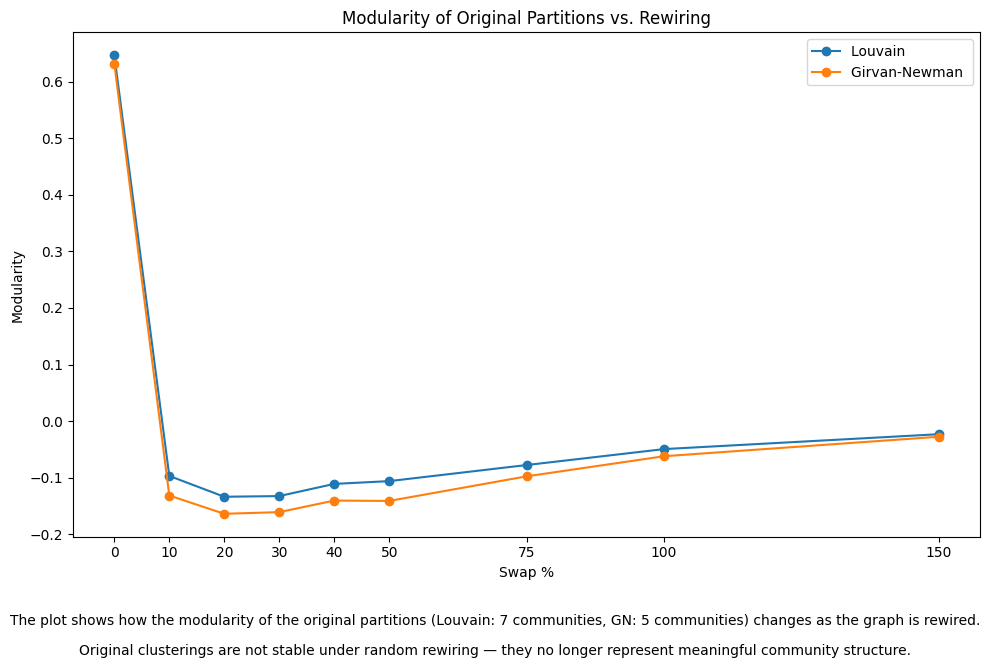

In [66]:
# Plot stability of original partitions

plt.figure(figsize=(10, 6))

plt.plot(df_stability['Swap %'], df_stability['Louvain (orig partition) modularity'], marker='o', label='Louvain ')
plt.plot(df_stability['Swap %'], df_stability['Girvan-Newman (orig partition) modularity'], marker='o', label='Girvan-Newman ')

plt.title('Modularity of Original Partitions vs. Rewiring')
plt.xlabel('Swap %')
plt.ylabel('Modularity')

plt.legend()

# First caption
plt.figtext(0.5, -0.05, 
    'The plot shows how the modularity of the original partitions (Louvain: 7 communities, GN: 5 communities) changes as the graph is rewired.', 
    wrap=True, horizontalalignment='center', fontsize=10)

# Second caption
plt.figtext(0.5, -0.10, 
    'Original clusterings are not stable under random rewiring — they no longer represent meaningful community structure.', 
    wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout()
plt.xticks(swap_percentages)
plt.show()


**Selected community clustering: Louvain algorithm (7 communities, modularity 0.6464 on original graph)**

Why Louvain was chosen for the project:

- Louvain clustering achieved a higher modularity (Q = 0.6464) compared to Girvan–Newman (Q = 0.6314) on the original graph — indicating a stronger community structure.

- Under increasing rewiring (swap %), Louvain showed gradual modularity decline (from Q = 0.6464 to Q = 0.1392 at 150%), while Girvan–Newman modularity collapsed rapidly (from Q = 0.6314 to near zero after 20% swaps — e.g., Q = 0.0108 at 10%, Q ≈ 0.001 at 150%).

- Louvain produced balanced community sizes (5–9 communities across swap %) and avoided over-fragmentation.
Girvan–Newman produced unstable and fragmented results (up to 16 small communities under noise).

- Louvain algorithm is more robust to random rewiring and computationally efficient, making it suitable for large-scale infrastructure planning for EV charging networks.

- The identified Louvain communities can guide station placement across both regional hubs and local cities, directly supporting the project’s goal to improve coverage and accessibility.

Conclusion: Based on the results, Louvain clustering is selected as the most suitable method for this project. Its stable, interpretable, and high-quality community structure will provide meaningful insights for optimizing the EV charging network in Germany.

##  Conclusions and Future Work

**1. Summarizing and interpreting the achieved results**

This project analyzed a proximity network of 126 German cities, where edges represent connections between cities that are less than 150 km apart. The goal was to provide insights for expanding the EV charging network in Germany.

The original graph showed a strong local structure and high connectivity:

- Nodes = 126, Edges = 1646, Density = 0.209

- Diameter = 7, Average shortest path = 2.92

- Average clustering coefficient = 0.7765

- Assortativity = 0.7057

After applying edge rewiring (10% to 150% swaps), the network topology evolved:

- Diameter decreased from 7 to 3 after 20% swaps.

- Average shortest path reduced from 2.92 to 1.83 (at 150% swap).

- Clustering coefficient dropped from 0.7765 to around 0.30 (at 150% swap).

- Assortativity became negative: from 0.7057 to −0.0458 at 150% swap.

These trends suggest that original local patterns (triangles and hubs) were lost, and the network became more globally connected and randomized.

**Centrality analysis identified key cities for EV charging station planning:**

- **Kassel, Ulm, Hannover** — cities with high betweenness centrality, acting as bridges for long-distance travel.

- **Koblenz, Weißenthurm** — cities consistently ranked in top positions across all centrality measures (degree, closeness, betweenness, eigenvector), representing stable and influential hubs.

Interestingly, major cities like Berlin (degree = 4), Munich (degree = 16), Hamburg (degree = 16) had low degree values, because they are geographically isolated in this proximity network — an important insight for improving long-distance EV connectivity.

**Community detection results:**

Community Detection (new partitions on rewired graphs):

- On the original graph, Louvain detected 7 communities with modularity Q = 0.6464, while Girvan–Newman found 5 communities with modularity Q = 0.6314.

- Louvain modularity decreased gradually (Q = 0.6464, Q = 0.1392 at 150% swap).

- Girvan–Newman modularity declined sharply (Q = 0.6314 at 0% swap, dropping to ~0.001 after only 10% swap), showing high sensitivity to noise.

- Louvain maintained stable community sizes (5–9); Girvan–Newman over-fragmented (up to 16).

- Louvain showed better robustness and interpretability under rewiring

**Original Partition Stability (graph partitioning test):**

We also tested how the original 7 Louvain communities and 5 Girvan-Newman communities perform under rewired graphs

- Original Louvain partition: modularity dropped from Q = 0.6464 to negative at 10% swap (Q = -0.0967).

- Original Girvan–Newman partition: modularity dropped from Q = 0.6314  more sharply (Q = -0.1313 at 10% swap).

- Both original partitions unstable under rewiring — Girvan Newman community structure  collapsed faster.



**2. Compare your results to the expected or desired outcomes in the original plan**

The original goal of the project was to support the expansion of electric vehicle (EV) charging infrastructure in Germany by identifying:

- Central cities that act as hubs,

- City groups that define natural regional clusters,

- Areas with few connections that need better coverage.

The results of the project strongly support these goals.

**Central hubs were successfully identified.**

- Cities like Koblenz and Weißenthurm ranked among the top 10 across all centrality measures. These cities are well connected and can serve as stable charging hubs.
- Also, Kassel, Ulm, and Hannover were highlighted for their high betweenness centrality, showing their importance in long-distance connectivity across Germany.

**City groups were clearly detected using community detection.**

- The Louvain algorithm found 7 well-structured communities with high modularity (Q = 0.6464). These groups reflect geographic and connectivity-based regions that match the planning needs. 

- The clustering result aligns well with the idea of developing region-based EV coverage strategies.

**Weakly connected areas were identified.**

- Cities like Berlin (degree = 4), Leipzig (degree = 9), Munich (degree = 16), and Hamburg (degree = 16) had surprisingly low degrees despite their high population and economic importance. This confirms the concern from the original plan that some major cities are geographically isolated in terms of proximity-based connectivity.

Given that the maximum degree in the network is 52 and the average degree is 26.13, these cities are significantly below average — highlighting their isolation within the proximity network despite being major urban centers 

**Community and modularity results confirm structure and stability.**

The Louvain method remained stable under network changes, which is useful for long-term infrastructure decisions. 

Its modularity started at Q = 0.6464 on the original graph and gradually declined to Q = 0.1392 after 150% edge rewiring. 

In contrast, Girvan–Newman’s modularity dropped sharply: from Q = 0.6314 on the original graph to just Q ≈ 0.0108 after only 10% rewiring, and remained close to Q ≈ 0.001 across higher swap levels. 

These results highlight Louvain’s robustness and Girvan–Newman’s sensitivity to structural change

Conclusion:
All main goals from Task 1 were addressed. The analysis provided measurable results that match the project’s objectives. The network structure, key cities, major cities with low connectivity and city groups were successfully identified. 

**3. Explain the generated value: How does the community clustering help the organization?**

The community clustering analysis gives important value for the company that operates EV charging stations in Germany.

- The Louvain algorithm identified 7 city groups with strong internal connections (modularity = 0.6464). These groups show natural regions where cities are more connected to each other than to outside cities.

By understanding these city groups, the company can plan regional expansion strategies. Instead of building stations randomly, it can focus on each group separately and ensure that every area has fair and balanced coverage. This also helps the company use its budget more efficiently.

For example, some groups include many large and medium cities (like the group with Cologne, Bonn, and Düsseldorf), while others cover more rural areas. Each group can get a custom plan based on its structure and population.

- The groups support better long-distance planning too. If each community is well-covered, drivers can travel across Germany conveniently.

In summary, the community clustering provides a clear map of regional EV coverage. It helps the company decide where to build, which areas to focus on, and how to improve network quality for all types of drivers.

**4. Recommend a course of action for the organization based on the results**

Based on the results, the organization should take the following actions to improve the EV charging network across Germany:

**a. Prioritize key bridge cities with high betweenness centrality**

- Cities like Kassel (betweenness = 0.1868), Ulm (0.1102), and Hannover (0.0750) play a central role in connecting different parts of the country.

 These cities should be the first candidates for new charging stations, as they improve long-distance travel and reduce the risk of disconnected regions.


**b. Support central hubs that appear important across multiple metrics**

- Koblenz and Weißenthurm ranked in the top 10 across all four centrality measures (degree, betweenness, closeness, eigenvector).
 These cities are strong local and regional hubs. Placing or upgrading stations here will improve accessibility for both short and medium-distance trips.

**c. Improve coverage in geographically isolated but important cities**

- Large cities such as Berlin (degree = 4), Munich (16), and Hamburg (16) are not well-connected in this proximity network. Even though they are economically important, their low degree shows possible isolation. 

Their very high population sizes make them high-priority locations despite their structural isolation in the network.

**d. Use the 7 Louvain-based communities for regional planning**

- Instead of treating the whole country as a single area, the company should develop regional expansion plans based on the 7 community clusters identified (modularity = 0.6464). 

This allows the company to balance the distribution of stations across different parts of Germany.

Conclusion:
These actions support both regional equity and national connectivity. They will help the organization use its resources effectively, provide better service to EV drivers, and support long-term market growth.

**5. Reflect on limitations and possible pitfalls of using these results**

While the results of this project provide helpful insights, there are several limitations and possible pitfalls that the organization should consider:

**a. Lack of real EV charging station data**

- The analysis was based only on the structure of the proximity graph between cities. 

It does not include real data on the current location, capacity, or usage of EV charging stations. This means that recommendations are based purely on network structure, not on actual demand or infrastructure gaps.

**b. Population was used only for visualization, not for calculations**

- Although population information was available for each city, it was only used to control the node size in the map visualizations. 

- No community detection or centrality calculation included population as a factor.

 As a result, cities were evaluated purely based on the structure of the proximity network. 
 
 While this supports a neutral, topology-based analysis, it does not reflect actual EV usage or regional demand patterns, which may depend on other external factors.

**c. Detected communities are sensitive to small changes in the graph**

- The Louvain and Girvan–Newman clusterings had high modularity on the original graph (Q = 0.646 and Q = 0.631, respectively). 

However, when their original partitions were applied to the rewired graphs, modularity dropped sharply — for example, Louvain’s modularity fell to Q = –0.0967 and Girvan–Newman’s to Q = –0.1313 after just 10% edge swaps.

 This indicates that the original community structures do not generalize well when the network topology changes.

**d. Over-reliance on static centrality rankings may miss dynamic factors**

Centrality measures like betweenness and closeness were computed on a static proximity graph, where connections are fixed based on geographic distance. 
While the real-world EV network may change over time with new stations or infrastructure, such developments do not alter the structure of this graph. 
As a result, the centrality rankings reflect proximity-based topology only and may not fully capture the future strategic importance of certain cities.


**6. Critical Discussion of the Methodology**

The overall methodology followed standard graph analysis practices and fulfilled the project goals. However, several areas could be improved or extended to make the results more robust and realistic:

**a. Graph Construction Choices**

- The graph was modeled as an undirected proximity network using a 150 km threshold.

- Edge weights were based on 1/distance, which favors closer cities. This is a reasonable simplification, but more realistic weights (e.g. transportation demand) could give better results.

**b. Centrality Measures and Static Analysis**

- The analysis used four standard centrality metrics: degree, closeness, betweenness, and eigenvector. This gave a good structural overview.

However, all metrics were computed on a static, undirected network. In reality, mobility and charging demand change over time. Dynamic models (e.g., temporal graphs) could simulate network growth and changing demand.

- Population data was used only for node size in visualizations, not in any metric or clustering. Future work could explore weighted centrality based on population or estimated EV usage per city.

**c. Graph Generation with Rewiring**

- Rewired graphs were created using double_edge_swap, which preserves degree but may not produce a truly random structure. More advanced null models, such as the configuration model, could provide better baselines for robustness testing.

- Only one rewiring method was applied. Exploring other transformations — like edge deletion,or regional isolation — might simulate more realistic infrastructure disruptions.

**d. Community Detection and Evaluation**

- The project applied Louvain and Girvan–Newman algorithms and selected Louvain for final analysis. This was a strong choice due to modularity and robustness.

However, modularity has known weaknesses, such as the resolution limit. Some small but meaningful communities may be merged.

- Also, algorithms were only evaluated by modularity. Adding secondary metrics (e.g. coverage, conductance) or running multiple trials to check stability would give a stronger validation.



**7. Ideas for Future Work**

**a.  Use population-weighted centrality**

In this project, centrality was computed purely based on graph structure. 

Future work could integrate population as a weighting factor (e.g., population-weighted betweenness) to prioritize cities not just by position but also by expected demand.

**b. Apply directed algorithms**

Currently, all analyses assume an undirected graph.

 Future work could incorporate real travel times, traffic data, or road network directions to build a more realistic weighted and directed network. This would enable the use of weighted closeness or PageRank, which may better reflect accessibility.

**c. Test alternative community detection methods**

- Louvain and Girvan–Newman were used here. Future experiments could try methods such as:

- Leiden algorithm – an improved modularity-based method with community resolution and robustness.

- Infomap – useful for flow-based dynamics, may detect communities aligned with EV traffic patterns.

**d. Evaluate community quality using additional metrics**

Modularity was the only clustering metric used. Future work could compute conductance, coverage, or surprise index to gain a more comprehensive understanding of the community structure.

**e. Simulate EV user behavior on the network**

To connect the graph structure with real-world utility, future work could combine proximity-based graph analysis with real-world data such as city population and EV adoption rates. This would support more targeted and realistic planning for where new stations are most needed.